# Practice Activity: Text Data - Spam Emails

In this activity you'll work with a small sample from the [Enron email corpus](https://en.wikipedia.org/wiki/Enron_Corpus). The [data set we'll use](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv) contains the subjects and bodies of a sample of e-mails that the Federal Energy Regulatory Commission (FERC) collected during their 2002 investigation of the energy company [Enron](https://en.wikipedia.org/wiki/Enron). Each row in the data set is an email and there are three columns

- subject: the subject of the email
- body: the text of the email
- spam: spam indicator, 1 if spam, 0 if not

For this activity we will only consider the body of the emails (though you could also include the subject using similar methods).

1\. The corpus is the body column in the [data set](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv); read this column in to create the corpus.


In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv")

df["body"] = df["body"].fillna("")

corpus = df["body"]
corpus.head()

0    we invoiced mirant americas for deal 705989 an...
1    because the payback was done for october 2001 ...
2    for december 1999 , since the volumes for tran...
3    i would think that the first contract should g...
4    welcome to the aol instant messenger ( sm ) se...
Name: body, dtype: object

2\. Describe in words in detail the steps that you would take to clean the emails and create the term-frequency matrix. We will write the code in the next part, but think carefully first about the process: how do we turn this text into tabular data?


Tokenize each document into lowercase words and remove punctuation. Then collect all unique tokens acorss the corpus and count how many times each term appears in each document. The resulting matrix has documents as rows, terms as columns, and counts as values.

3\. Use `CountVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `CountVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.


In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
vec = CountVectorizer()
tf_matrix = vec.fit_transform(corpus)

tf_df = pd.DataFrame(tf_matrix.toarray(), columns=vec.get_feature_names_out())
print(tf_df)

      00  000  0000  000000  000000000002858  000000000049773  000080  0001  \
0      0    1     0       0                0                0       0     0   
1      0    0     0       0                0                0       0     0   
2      0    1     0       0                0                0       0     0   
3      0    0     0       0                0                0       0     0   
4      0    0     0       0                0                0       0     0   
...   ..  ...   ...     ...              ...              ...     ...   ...   
1985   0    0     0       0                0                0       0     0   
1986   0    0     0       0                0                0       0     0   
1987   0    0     0       0                0                0       0     0   
1988   0    0     0       0                0                0       0     0   
1989   0    0     0       0                0                0       0     0   

      00020608  0004  ...  zyban  zykfe  zyl  zynsd

4\. Explain what a document frequency (DF) is, and the idea of an IDF. Why might we use TF-IDF rather than just TF? This question is asking about concepts rather than computations.


DF is the number of docs containing a term. The idea of IDF is that it weighs rarer terms higher and common terms lower. We would use TF-IDF beacuse it does a better job of identifying terms that actually distinguishes documents and down-weighs terms like "the."

5\. Use `TfidfVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `TfidfVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.

In [3]:
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(corpus)

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vec.get_feature_names_out())
print(tfidf_df)

       00       000  0000  000000  000000000002858  000000000049773  000080  \
0     0.0  0.106624   0.0     0.0              0.0              0.0     0.0   
1     0.0  0.000000   0.0     0.0              0.0              0.0     0.0   
2     0.0  0.097060   0.0     0.0              0.0              0.0     0.0   
3     0.0  0.000000   0.0     0.0              0.0              0.0     0.0   
4     0.0  0.000000   0.0     0.0              0.0              0.0     0.0   
...   ...       ...   ...     ...              ...              ...     ...   
1985  0.0  0.000000   0.0     0.0              0.0              0.0     0.0   
1986  0.0  0.000000   0.0     0.0              0.0              0.0     0.0   
1987  0.0  0.000000   0.0     0.0              0.0              0.0     0.0   
1988  0.0  0.000000   0.0     0.0              0.0              0.0     0.0   
1989  0.0  0.000000   0.0     0.0              0.0              0.0     0.0   

      0001  00020608  0004  ...  zyban  zykfe  zyl 

6\. Remember that the data set also contains an indicator of whether or not the email is spam. In this part you will use descriptive statistics and plots to compare the spam and non-spam emails in terms of their text, represented by the TF and TF-IDF matrices. This part is pretty open ended. First brainstorm some questions or things to investigate, and then write the code to produce relevant summaries.

Note: there are 10 emails for which the spam indicator is missing. You should remove them for this part. We'll come back to them soon.


In [4]:
known = df[df["spam"].notna()].copy()
unknown = df[df["spam"].isna()].copy()

tf_known = tf_df.loc[known.index].copy()
tf_known["spam"] = known["spam"].values

spam_mean_tf = tf_known[tf_known["spam"] == 1].drop(columns="spam").mean()
ham_mean_tf = tf_known[tf_known["spam"] == 0].drop(columns="spam").mean()

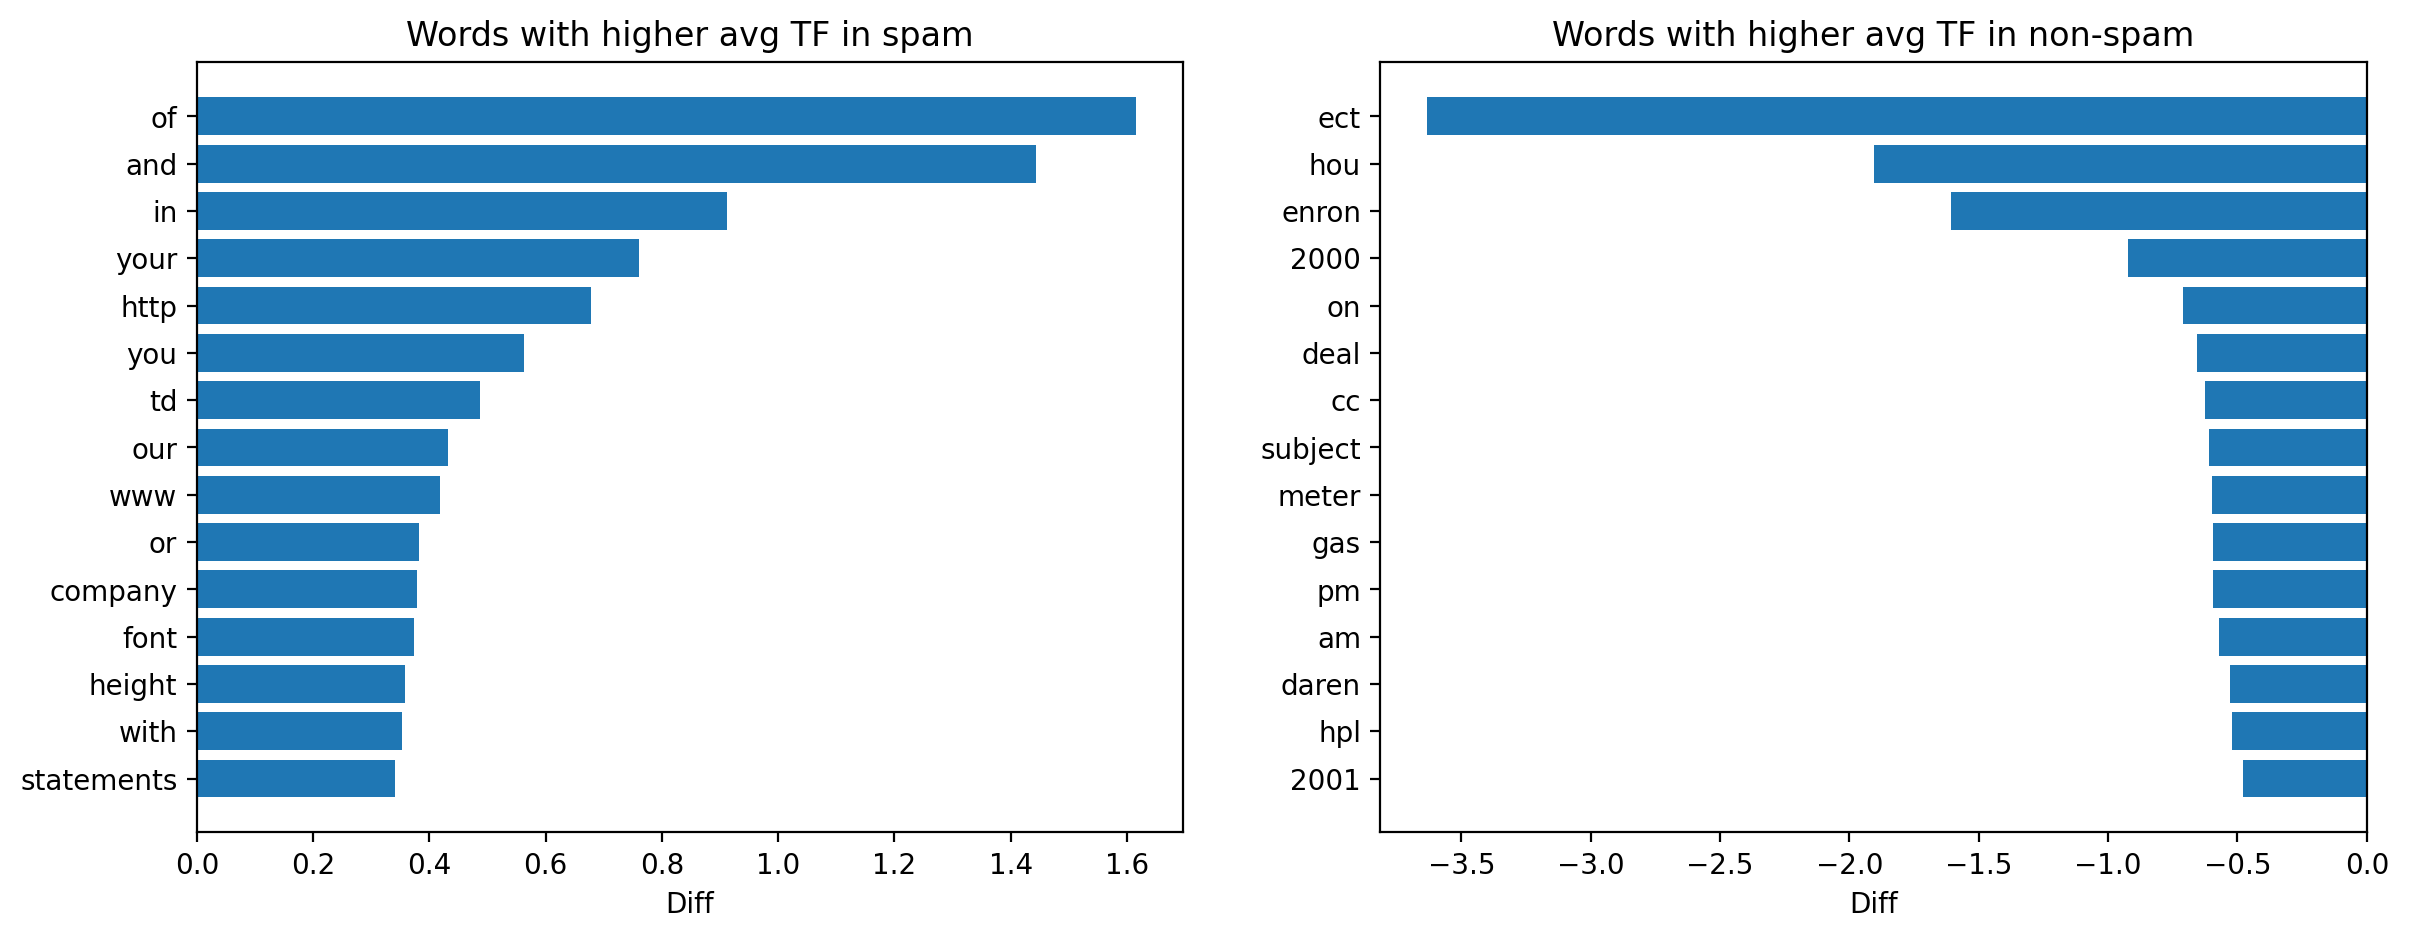

In [5]:
import matplotlib.pyplot as plt

diff = spam_mean_tf - ham_mean_tf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_spam_words = diff.sort_values(ascending=False).head(15)
axes[0].barh(top_spam_words.index, top_spam_words.values)
axes[0].set_title("Words with higher avg TF in spam")
axes[0].set_xlabel("Diff")
axes[0].invert_yaxis()

top_ham_words = diff.sort_values(ascending=True).head(15)
axes[1].barh(top_ham_words.index, top_ham_words.values)
axes[1].set_title("Words with higher avg TF in non-spam")
axes[1].set_xlabel("Diff")
axes[1].invert_yaxis()

plt.show()

7\. Now consider the 10 emails for which the true spam status is unknown. How might you decide if each email is spam or not? Brainstorm some ideas before proceeding. How can you use the TF and TF-IDF matrices for emails with known spam status?

Compute cosine distance between each unknown email's vector and all known emails' vectors. Classify based on the spam labels of the closest neighbors.

8\. Consider just one email with unknown spam status, with `loc` 1980. Compute the cosine distance between the TF representation of this email and the TF representation of each of the emails with known spam status.

In [6]:
from scipy.spatial.distance import cosine

email_1980_tf = tf_df.loc[1980].values

distances_tf = {}
for idx in known.index:
    distances_tf[idx] = cosine(email_1980_tf, tf_df.loc[idx].values)

dist_tf_df = pd.DataFrame({
    "cosine_distance": pd.Series(distances_tf),
    "spam": df.loc[known.index, "spam"].values
})

print(dist_tf_df)

/Users/julian/Library/Python/3.9/lib/python/site-packages/scipy/spatial/distance.py:647: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


      cosine_distance  spam
0            0.736928   0.0
1            0.542990   0.0
2            0.775802   0.0
3            0.653954   0.0
4            0.519088   0.0
...               ...   ...
1975         0.944996   1.0
1976         0.649040   1.0
1977         0.448669   1.0
1978         0.693219   1.0
1979         0.931826   1.0

[1980 rows x 2 columns]


9\. Sort the results of the previous part to examine the emails with known spam status that are most similar to the unknown email. If you had to determine if the unknown email was spam or not, which would you pick and why?

In [7]:
sorted_tf = dist_tf_df.sort_values("cosine_distance")
print(sorted_tf.head(5))

      cosine_distance  spam
1889         0.393060   1.0
1032         0.398488   1.0
1376         0.408606   1.0
714          0.414644   0.0
1110         0.415807   1.0


I would determine that it's spam because 4 out of the top 5 most similar emails are spam.

10\. Repeat the two previous parts using TF-IDF instead of TF. Do the results change?

In [8]:
email_1980_tfidf = tfidf_df.loc[1980].values

distances_tfidf = {}
for idx in known.index:
    distances_tfidf[idx] = cosine(email_1980_tfidf, tfidf_df.loc[idx].values)

dist_tfidf_df = pd.DataFrame({
    "cosine_distance": pd.Series(distances_tfidf),
    "spam": df.loc[known.index, "spam"].values
})

sorted_tfidf = dist_tfidf_df.sort_values("cosine_distance")
print(sorted_tfidf.head(10))

/Users/julian/Library/Python/3.9/lib/python/site-packages/scipy/spatial/distance.py:647: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


      cosine_distance  spam
1032         0.755245   1.0
1977         0.780917   1.0
48           0.787975   0.0
1689         0.790205   1.0
1796         0.795094   1.0
180          0.797415   0.0
586          0.798537   0.0
1376         0.799377   1.0
279          0.799969   0.0
1021         0.801259   1.0


In [9]:
print(sorted_tfidf.head(5))

      cosine_distance  spam
1032         0.755245   1.0
1977         0.780917   1.0
48           0.787975   0.0
1689         0.790205   1.0
1796         0.795094   1.0


Also, 4 out of top 5 closest docs are spam. So I would classify as spam.

11\. Now proceed in a similar manner to "guess" the spam status of each of the unknown emails.

In [11]:
k = 5
results = []

for uid in unknown.index:
    vec_u = tfidf_df.loc[uid].values
    dists = {}
    for kid in known.index:
        dists[kid] = cosine(vec_u, tfidf_df.loc[kid].values)

    nearest = pd.Series(dists).sort_values().head(k)
    nearest_spam = df.loc[nearest.index, "spam"]
    pred = int(nearest_spam.mean() >= 0.5)

    results.append({
        "email_index": uid,
        "predicted_spam": pred,
        "neighbor_spam_proportion": nearest_spam.mean()
    })

pd.DataFrame(results)

/Users/julian/Library/Python/3.9/lib/python/site-packages/scipy/spatial/distance.py:647: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


,email_index,predicted_spam,neighbor_spam_proportion
0,1980,1,0.8
1,1981,0,0.0
2,1982,0,0.2
3,1983,0,0.0
4,1984,0,0.0
5,1985,1,0.8
6,1986,1,1.0
7,1987,1,1.0
8,1988,1,1.0
9,1989,0,0.4
